In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
smeshEnvironment = pd.read_csv("concatSmeshData/f864_environmentMetrics.csv")
smeshEnvironment.sort_values(by = "datetime", inplace = True, ignore_index = True)
smeshEnvironment['datetime'] = pd.to_datetime(smeshEnvironment['datetime'])
print(smeshEnvironment)
smeshEnvironment['datetime'] = smeshEnvironment['datetime'].dt.tz_localize("US/Pacific", ambiguous=True)


smeshEnvironment.set_index("datetime", inplace = True)
# smeshEnvironment = smeshEnvironment.dropna(subset=['windDirection', 'windSpeed'])

# smeshEnvironment = smeshEnvironment[["temperature","relativeHumidity","barometricPressure","windDirection","windSpeed"]].resample('20min').mean()
print(smeshEnvironment)

                        datetime    fromNode  temperature  relativeHumidity  \
0     2025-10-19 13:18:48.094646  0x433acb14    31.738941         24.778002   
1     2025-10-19 13:24:48.218287  0x433acb14    32.772938         25.279995   
2     2025-10-19 13:30:49.984250  0x433acb14    31.877136         25.591957   
3     2025-10-19 13:44:28.353034  0x433b0b38    29.431767         31.269491   
4     2025-10-19 13:45:29.092311  0x433b0b38    29.532960         31.185745   
...                          ...         ...          ...               ...   
10145 2025-11-04 06:22:25.942679  0x433b0b38    16.132128         70.859130   
10146 2025-11-04 07:13:26.895751  0x433aafcc    18.223124         63.513668   
10147 2025-11-04 07:52:23.926936  0x433b0098    21.001902         56.280064   
10148 2025-11-04 08:04:27.365803  0x433b0b38    17.244420         67.763640   
10149 2025-11-04 08:43:32.711574  0x433aafcc    18.073030         63.564810   

       barometricPressure  gasResistance    iaq  wi

In [ ]:
#Interpolate this to make it more uniform

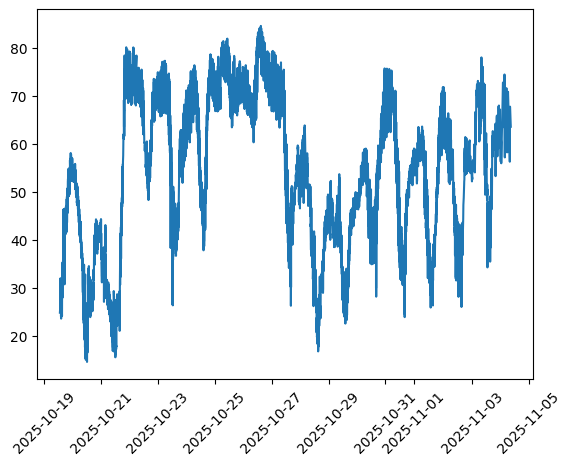

In [14]:
plt.plot(smeshEnvironment.index, smeshEnvironment['relativeHumidity'])
plt.xticks(rotation=45)
plt.show()


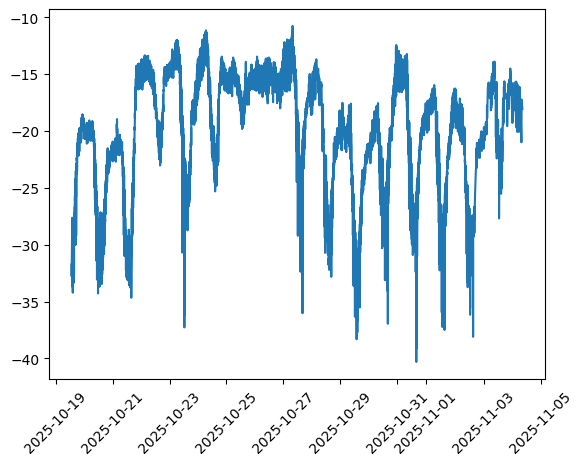

In [15]:
plt.plot(smeshEnvironment.index, -smeshEnvironment['temperature'])
plt.xticks(rotation=45)
plt.show()

In [18]:
corr = np.corrcoef(smeshEnvironment['temperature'], smeshEnvironment['relativeHumidity'])[0,1]
print(corr)

-0.900167681723703


In [34]:
purpleAirSensorLocations = pd.read_csv("PurpleAir Download 11-7-2025/PurpleAirLocations.csv")
display(purpleAirSensorLocations.head())
sensorNames = []
dataArray = []
for sensorName in purpleAirSensorLocations["Sensor Name"]:
    dataArray.append(pd.read_csv("PurpleAir Download 11-7-2025/" + sensorName + ".csv"))
    sensorNames.append(sensorName)
    
for i, data in enumerate(dataArray):
    data['datetime'] = pd.to_datetime(data['time_stamp'])
    # data = data[data['pm2.5_atm'] <= 10040]
    # data.loc[:,'pm2.5_atm'] = data['pm2.5_atm'].where(data['pm2.5_atm'] <= 80, 0)


    data.set_index("datetime", inplace = True)
    # data.index = data.index.tz_convert("UTC") 
    dataResampled = data[["humidity", "temperature", "pressure", "pm2.5_atm"]].resample('10min').mean()
    dataResampled.reset_index(inplace = True)
    dataArray[i] = dataResampled


pepperwoodPreserve = dataArray[purpleAirSensorLocations.index[purpleAirSensorLocations["Sensor Name"] == "Pepperwood Preserve"][0]]
franzValley= dataArray[purpleAirSensorLocations.index[purpleAirSensorLocations["Sensor Name"] == "Franz Valley"][0]]
meadowSprings = dataArray[purpleAirSensorLocations.index[purpleAirSensorLocations["Sensor Name"] == "Meadow Springs"][0]]
outside8566 = dataArray[purpleAirSensorLocations.index[purpleAirSensorLocations["Sensor Name"] == "8566 Outside"][0]]


print(len(pepperwoodPreserve))

,Sensor Name,Sensor ID,Latitude,Longitude
0,Pepperwood Preserve,157135,38.569330,-122.690053
1,Franz Valley,103800,38.581280,-122.610553
2,Meadow Springs,132747,38.556707,-122.723024
3,8566 Outside,70025,38.552829,-122.722210


1296


In [35]:
print(sensorNames)

['Pepperwood Preserve', 'Franz Valley', 'Meadow Springs', '8566 Outside']


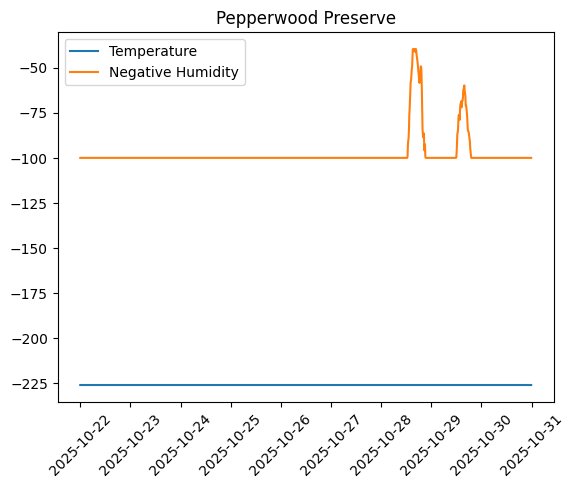

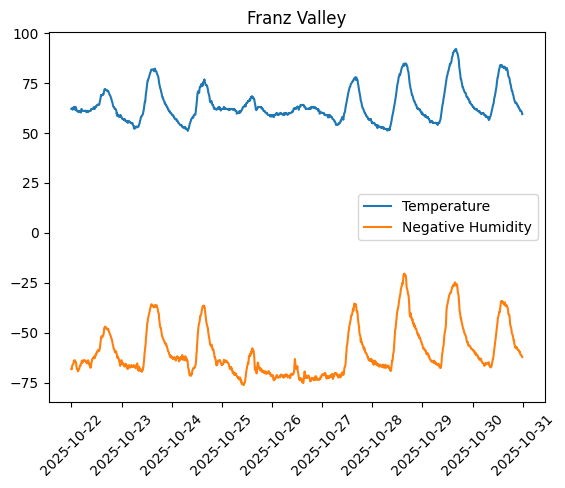

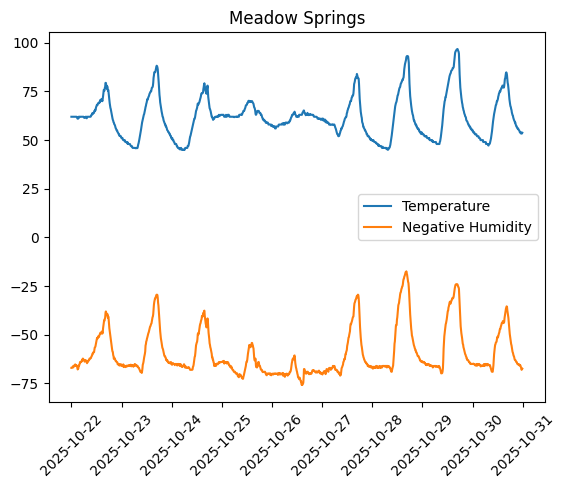

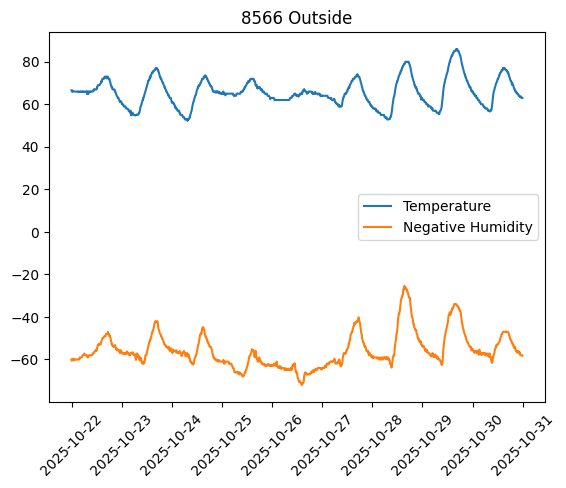

In [39]:
for i,data in enumerate(dataArray):
    plt.plot(data["datetime"], data["temperature"], label = "Temperature")
    plt.plot(data["datetime"], -data["humidity"], label = "Negative Humidity")
    plt.legend()
    plt.title(sensorNames[i])
    plt.xticks(rotation = 45)
    plt.show()
# plt.plot(pepperwoodPreserve["datetime"], pepperwoodPreserve["temperature"])